# The Colab Implementation (Van der Pol Oscillator)
We will generate a synthetic physics dataset (a Van der Pol oscillator limit cycle) and train a single-encoder LeJEPA to predict its future states. Because this uses a lightweight 1D-CNN and linear time SIGReg, it will run instantly on a free T4 without OOM issues.

## Cell 1: Environment and Data Generation
We generate sequences of a non-linear oscillator. This mimics the cyclical but complex nature of industrial sensor data.

In [ ]:
# Install the library directly from the GitHub repository
!pip install -q git+https://github.com/galilai-group/lejepa.git torch

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import lejepa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# Generate Synthetic Van der Pol Oscillator Data (Limit Cycle Physics)
def generate_vdp_data(num_samples=5000, seq_len=100, dt=0.05):
    data = []
    for _ in range(num_samples):
        # Random initial conditions
        x, y = torch.randn(1).item(), torch.randn(1).item()
        seq = []
        for _ in range(seq_len):
            # Van der Pol equations
            dx = y
            dy = (1.0 - x**2) * y - x
            x += dx * dt
            y += dy * dt
            seq.append([x, y])
        data.append(seq)
    # Shape: [Batch, Channels, Sequence Length]
    return torch.tensor(data, dtype=torch.float32).transpose(1, 2)

print("Generating synthetic physics dataset...")
dataset = generate_vdp_data()
dataloader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)
print(f"Dataset shape: {dataset.shape}")

Running on: cuda
Generating synthetic physics dataset...
Dataset shape: torch.Size([5000, 2, 100])


## Cell 2: The LeJEPA Architecture
Notice there is only one encoder. We handle the masking entirely in the forward pass.

In [ ]:
class TimeSeriesEncoder(nn.Module):
    def __init__(self, in_channels=2, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(32, embed_dim, kernel_size=3, padding=1),
        )
        # Required to prevent singular matrix errors in the SIGReg calculation
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Input: [B, C, L] -> Output: [B, L, Embed_Dim]
        out = self.net(x).transpose(1, 2)
        return self.norm(out)

class Predictor(nn.Module):
    def __init__(self, embed_dim=64, context_len=70, target_len=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim * context_len, 256),
            nn.GELU(),
            nn.Linear(256, embed_dim * target_len)
        )
        self.target_len = target_len
        self.embed_dim = embed_dim

    def forward(self, context):
        B = context.size(0)
        flat_context = context.reshape(B, -1)
        pred = self.net(flat_context)
        return pred.reshape(B, self.target_len, self.embed_dim)

# Initialize models
encoder = TimeSeriesEncoder().to(device)
predictor = Predictor(context_len=70, target_len=30).to(device)

# Initialize the efficient O(N) SIGReg
univariate_test = lejepa.univariate.EppsPulley(n_points=17)
sigreg_fn = lejepa.multivariate.SlicingUnivariateTest(
    univariate_test=univariate_test,
    num_slices=256
).to(device)

optimizer = optim.AdamW(list(encoder.parameters()) + list(predictor.parameters()), lr=1e-3)

## Cell 3: The Training Loop (The Core Logic)
This is where the magic happens. Watch how the data is split without any stop-gradients.

In [ ]:
epochs = 20
lambda_weight = 0.05

print("Starting LeJEPA Predictive Training...")

for epoch in range(epochs):
    encoder.train()
    predictor.train()
    total_loss, total_mse, total_sigreg = 0, 0, 0

    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # 1. Single Pass Encoding
        embeddings = encoder(batch)

        # 2. Universal Constraint (SIGReg on the entire sequence)
        flat_embeddings = embeddings.reshape(-1, 64)
        sigreg_loss = sigreg_fn(flat_embeddings)

        # 3. Logical Split (Block Masking the future)
        context = embeddings[:, :70, :]
        target = embeddings[:, 70:, :]

        # 4. Predict the missing states
        predictions = predictor(context)

        # 5. Calculate Error
        mse_loss = nn.functional.mse_loss(predictions, target)

        # 6. Backpropagate the combined objective
        loss = mse_loss + (lambda_weight * sigreg_loss)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_mse += mse_loss.item()
        total_sigreg += sigreg_loss.item()

    print(f"Epoch {epoch+1:02d} | Total: {total_loss/len(dataloader):.4f} | MSE: {total_mse/len(dataloader):.4f} | SIGReg: {total_sigreg/len(dataloader):.4f}")

print("Training Complete. Proceed to evaluate the latent space geometry.")

Starting LeJEPA Predictive Training...
Epoch 01 | Total: 236.7318 | MSE: 0.5922 | SIGReg: 4722.7927
Epoch 02 | Total: 153.1084 | MSE: 0.1254 | SIGReg: 3059.6603
Epoch 03 | Total: 125.0167 | MSE: 0.0636 | SIGReg: 2499.0614
Epoch 04 | Total: 105.2131 | MSE: 0.0559 | SIGReg: 2103.1441
Epoch 05 | Total: 90.9768 | MSE: 0.0490 | SIGReg: 1818.5562
Epoch 06 | Total: 83.0134 | MSE: 0.0401 | SIGReg: 1659.4656
Epoch 07 | Total: 80.5140 | MSE: 0.0397 | SIGReg: 1609.4842
Epoch 08 | Total: 77.7068 | MSE: 0.0465 | SIGReg: 1553.2042
Epoch 09 | Total: 77.9802 | MSE: 0.0449 | SIGReg: 1558.7071
Epoch 10 | Total: 78.3379 | MSE: 0.0446 | SIGReg: 1565.8658
Epoch 11 | Total: 78.3023 | MSE: 0.0419 | SIGReg: 1565.2086
Epoch 12 | Total: 77.8607 | MSE: 0.0553 | SIGReg: 1556.1071
Epoch 13 | Total: 76.5172 | MSE: 0.0351 | SIGReg: 1529.6430
Epoch 14 | Total: 78.1522 | MSE: 0.0336 | SIGReg: 1562.3719
Epoch 15 | Total: 76.7702 | MSE: 0.0378 | SIGReg: 1534.6477
Epoch 16 | Total: 77.5010 | MSE: 0.0355 | SIGReg: 1549.30

Extracting embeddings...
Reducing dimensions from 64 to 2 via PCA...


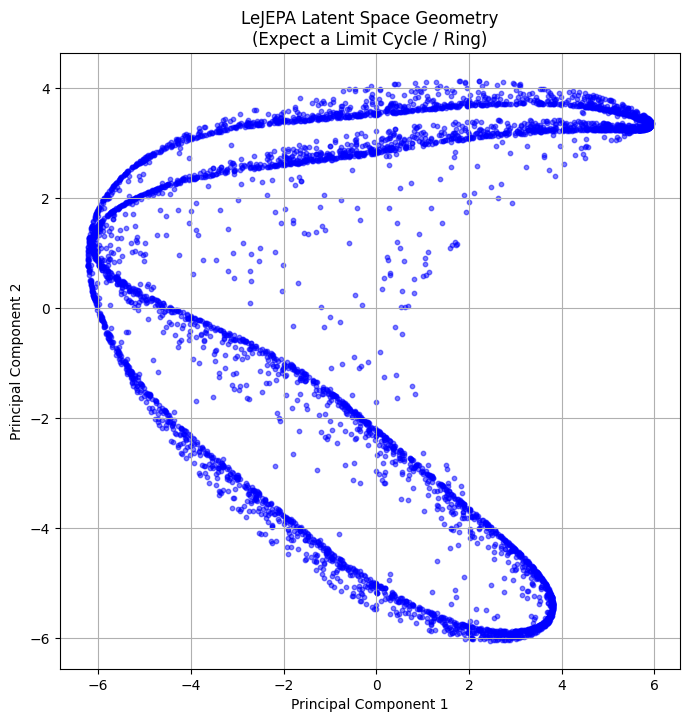

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Extracting embeddings...")
encoder.eval()
all_embeddings = []

# Pass the data through the trained encoder without gradients
with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)
        emb = encoder(batch)
        # We only care about the geometry of the context features
        # Take the embedding at the final context step (timestep 69)
        context_end_states = emb[:, 69, :].cpu().numpy()
        all_embeddings.append(context_end_states)

import numpy as np
all_embeddings = np.concatenate(all_embeddings, axis=0)

print("Reducing dimensions from 64 to 2 via PCA...")
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Plot the geometry
plt.figure(figsize=(8, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.5, s=10, c='blue')
plt.title("LeJEPA Latent Space Geometry\n(Expect a Limit Cycle / Ring)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()